# Lab 4: Enhancing the Bike Sharing System

Welcome to **Lab 4** of the Modeling & Simulation course! In this laboratory session, we will build upon the foundations laid in the previous labs to enhance our bike-sharing system simulation. This lab introduces the concept of **time slot-specific probabilities**, allowing you to model varying bike usage patterns throughout the day. Additionally, you will implement bike maintenance and downtime, develop a rebalancing mechanism, track customer satisfaction, and undertake a **graded assignment** to design and implement a comprehensive simulation project.

---

## Table of Contents

1. [Recap of Previous Labs](#recap)
2. [Introduction to Time Slot-Specific Probabilities](#time-slots)
   - [Understanding Time Slots](#understanding-time-slots)
3. [Implementing Time Slot-Specific Probabilities](#implementing-time-slots)
   - [Defining Time Slots](#defining-time-slots)
4. [Graded Assignment Overview](#assignment)

---

## <a name="recap"></a>1. Recap of Previous Labs

### Lab 1: Python Introduction
- Gained proficiency in Python programming.
- Learned fundamental programming concepts such as variables, data types, control structures, functions, and basic I/O operations.

### Lab 2: Basic Bike Sharing System Modeling
- Developed a simplified bike-sharing system using Python classes.
- Modeled entities such as stations, bikes, and trips.
- Implemented basic trip generation and analyzed system behavior over a short period.

### Lab 3: Introduction to SimPy
- Introduced SimPy, a discrete-event simulation library in Python.
- Reimplemented the bike-sharing system using SimPy constructs like environments, processes, and resources.
- Explored extensions including variable trip durations, rebalancing strategies, and customer satisfaction tracking.

---

## <a name="time-slots"></a>2. Introduction to Time Slot-Specific Probabilities

In real-world scenarios, bike usage varies throughout the day. To simulate this variability, we introduce **time slot-specific probabilities**. This enhancement allows the simulation to reflect different demand levels during various periods, such as morning rush hours and midday.

### <a name="understanding-time-slots"></a>Understanding Time Slots

- **Time Slots:** Defined periods within a day where bike trip probabilities differ.
- **Recurring Pattern:** Time slots repeat every simulated day, enabling multi-day simulations.
- **Example Time Slots:**
  - **Morning Start (0-120 minutes):** Initial hours with increasing demand.
  - **Midday (120-720 minutes):** Peak hours with stable high demand.

### <a name="mapping-time"></a>Mapping Simulation Time to Real-Time

To create realistic simulations, map simulation minutes to actual day times.

- **Simulation Start Time:** 6:00 AM
- **Morning Start:** 6:00 AM - 8:00 AM (0-120 minutes)
- **Midday:** 8:00 AM - 6:00 PM (120-720 minutes)
- **Simulation Duration:** 20 days (12 hours/day) → 14400 minutes

---

## <a name="implementing-time-slots"></a>3. Implementing Time Slot-Specific Probabilities

### <a name="defining-time-slots"></a>Defining Time Slots

Define time slots with specific trip probability matrices within a single day. Use the modulo operation to map the current simulation time to the appropriate time slot.

```python
# Define time slots for a single day
time_slots = [
    {
        'name': 'morning_start',
        'start': 0,       # 0 minutes into the day (6:00 AM)
        'end': 120,       # 2 hours
        'prob_matrix': {
            ('A', 'B'): 0.4,
            ('B', 'A'): 0.6,
            ('A', 'C'): 0.2,
            ('C', 'A'): 0.5,
            ('B', 'C'): 0.3,
            ('C', 'B'): 0.4,
            ('A', 'D'): 0.3,
            ('D', 'A'): 0.2,
        }
    },
    {
        'name': 'midday',
        'start': 120,      # 2 hours into the day (8:00 AM)
        'end': 720,        # 12 hours total (6:00 PM)
        'prob_matrix': {
            ('A', 'B'): 0.2,
            ('B', 'A'): 0.3,
            ('A', 'C'): 0.1,
            ('C', 'A'): 0.2,
            ('B', 'C'): 0.25,
            ('C', 'B'): 0.35,
            ('A', 'D'): 0.15,
            ('D', 'A'): 0.25,
        }
    }
    # Add more time slots if needed
]

# Define default probability matrix if no slot matches
default_prob_matrix = {
    ('A', 'B'): 0.05,
    ('B', 'A'): 0.05,
    ('A', 'C'): 0.05,
    ('C', 'A'): 0.05,
    ('B', 'C'): 0.05,
    ('C', 'B'): 0.05,
    ('A', 'D'): 0.05,
    ('D', 'A'): 0.05,
}


In [16]:
# Start from the code you've implemented in lab 3, add time-slot specific probabilities below



## <a name="assignment"></a>Graded Assignment Overview

Design and implement an enhanced bike-sharing system simulation using **SimPy**, incorporating advanced features to model a realistic and complex environment. Your simulation should build upon the concepts learned in previous labs and include the following components:

---

Your simulation must include the following elements:

### 1. Multiple Stations:

- **Minimum of Four stations** with varying capacities and initial bike counts.
- Each station should have a unique name, capacity, and initial number of bikes.

### 2. Time-Dependent Trip Probabilities:

- Implement trip probabilities that change based on different time slots (e.g., morning start, midday).
- Define at least **two distinct time slots** with different probability matrices.
- Ensure that time slots are **recurring daily** over the simulation period.

### 3. Bike Maintenance and Downtime:

- Model bike failures with a specified failure probability during trips.
- Implement a repair process that handles broken bikes, making them unavailable until repaired. The implementation details are up to your imagination.
- Track and report the number of bikes under maintenance.

### 4. Rebalancing Mechanism:

- Develop a rebalancing strategy to redistribute bikes between stations based on current demand and bike levels.
- Rebalancing should occur at regular intervals (e.g., every 20 minutes) and follow defined criteria.

### 5. Customer Satisfaction Tracking:

- Track the number of **unhappy customers** who cannot rent a bike due to unavailability.
- Track the number of **unhappy customers** who cannot return a bike due to full stations.

### 6. Data Collection and Visualization:

- Collect data on **bike levels** at each station over time.
- Collect data on **broken bikes** and maintenance activities.
- Collect data on **customer satisfaction** metrics.
- Generate plots to visualize:
  - **Bike levels** at each station over time.
  - **Number of bikes under maintenance**.
  - **Customer satisfaction metrics** (e.g., unhappy customers over time).

### 7. Simulation:

- Allow the simulation to run for a configurable duration (e.g., **20 days**).
- Parameters such as the number of stations, capacities, initial bikes, trip probabilities, maintenance rates, rebalancing intervals, and simulation duration should be easily adjustable.
- Simulate and observe the system with various parameters.

---

#### (Optional) Money Earning Mechanism:

- Introduce a system where the bike-sharing service earns **money based on bike rentals** (e.g., per hour rented).
- Track and report **total earnings** over the simulation period.

## What to Look For in Your Simulations

The primary objective of this lab is to enable you to create a realistic and dynamic simulation of a bike-sharing system that accounts for daily usage patterns, system maintenance, and operational strategies. Things to look for:

* Bike Availability: Assess how well the rebalancing mechanism maintains adequate bike levels across stations.
* Maintenance Impact: Evaluate the effect of bike failures on system performance and customer satisfaction.
* Customer Satisfaction: Analyze the number of unhappy customers and identify patterns or causes.

Write down a couple of observations from your simulations to accompany the presentation of your system.

## Grading

You will present your work in the upcoming laboratory, showing your system implementation and 1-3 simulations that you ran. The simulations should be accompanied by visual plots and you are encouraged to present any interesting observations about your system (e.g. with environment setup X the customer dissatisfaction drops significantly when increasing the rebalancing frequency to value y).

The project grade will be determined by the grade of completion of your system (how much of the project task has been implemented), as well as your understanding of it. The latter will be assessed through some basic questions about your model/system/simulations.

*Note: Where not strongly specified, you are free to design a subsystem/idea however you find best fit, e.g. points 2, 3 and 4 can have many different subsystem designs. There is no one correct way to do it.

In [17]:
# Libraries
import simpy
import random
import matplotlib.pyplot as plt

In [18]:
# Station class
class Station:
    def __init__(self, env, name, capacity, init_bikes):
        self.env = env
        self.name = name
        self.capacity = capacity
        self.bikes = simpy.Container(env, init=init_bikes, capacity=capacity)

In [19]:
# --- Global parameters ----
MIN_PER_DAY = 1440
BREAKDOWN_PROB = 0.01
REPAIR_TIME = 30

REBALANCE_TIME = 30
REBALACE_TRESHOLD = 30
REBALANCE_BIKE_COUNT = 3

current_broken_bike = 0
unhappy_customers_rent = 0
unhappy_customers_return = 0
bikes_under_repair = []
unhappy_rent = []
unhappy_return = []

In [20]:
# --- Repair process -------
# Cerinta 3
def repair_bike_process(env, from_station, to_station, repair_time):
    # folosim varriabila globala pentru a tine evidenta bicicletelor stricate
    global current_broken_bike
    current_broken_bike += 1

    print(f"Time {env.now}: Bike broke between {from_station.name} -> {to_station.name}")

    # timp de reparatie in care bicicleta este indisponibila
    yield env.timeout(repair_time)

    # bicicleta este reparata, scadem numarul de biciclete stricate
    current_broken_bike -= 1

    # incercam sa returnam bicicleta la statia destinatie
    if to_station.bikes.level < to_station.capacity:
        yield to_station.bikes.put(1)
        print(f"Time {env.now}: Repaired bike returned to {to_station.name}")
    else:
        if from_station.bikes.level < from_station.capacity:
            yield from_station.bikes.put(1)
            print(f"Time {env.now}: Repaired bike returned to {from_station.name}")
        else:
            print(f"Time {env.now}: Repaired bike couldn't be placed.")

In [21]:
# --- Bike trip process ---=
def bike_trip(env, from_station, to_station, trip_duration, breakdown_prob=BREAKDOWN_PROB, repair_time=REPAIR_TIME):
    # Cerinta 5 
    global unhappy_customers_rent, unhappy_customers_return


    if from_station.bikes.level > 0:
        yield from_station.bikes.get(1)
        print(f"Time {env.now}: Bike taken from {from_station.name}")
    else:
        print(f"Time {env.now}: No bikes available at {from_station.name}")
        # daca nu sunt biciclete, avem un client nefericit la inchiriere
        unhappy_customers_rent += 1
        return 

    yield env.timeout(trip_duration)

    if random.random() < breakdown_prob:
        env.process(repair_bike_process(env, from_station, to_station, repair_time))
        return   # procesele sunt paralele, folosim return pentru ca bicicleta nu e in functiune - e in reparatie

    if to_station.bikes.level < to_station.capacity:
        yield to_station.bikes.put(1)
        print(f"Time {env.now}: Bike returned to {to_station.name}")
    else:
        print(f"Time {env.now}: No docks available at {to_station.name}, returning bike to {from_station.name}")

        # daca nu sunt locuri de returnat, avem un client nefericit la returnare
        unhappy_customers_return += 1

        yield env.timeout(trip_duration)
        if from_station.bikes.level > 0:
            yield from_station.bikes.put(1)
            print(f"Time {env.now}: Bike returned to {from_station.name}")
        else:
            print(f"Time {env.now}: No docks available at {from_station.name}, bike lost.")

In [22]:
# --- Trip generation -------
def generate_trips(env):
    while True:
        # Cerinta 2
        prob_matrix = get_current_prob_matrix(env.now)
        for (from_station, to_station), prob in prob_matrix.items():
            if random.random() < prob:
                trip_duration = random.randint(3, 7)   # durata calatoriei intre 3 si 7 minute
                env.process(bike_trip(env, from_station, to_station, trip_duration))
        yield env.timeout(1)

In [23]:
# --- Monitors -----
def monitor_stations(env, stations, bike_levels):
    while True:
        for station in stations:
            # in lista corespunzatoare fiecarei statii, tinem un tuplu (timp, nr biciclete curente)
            bike_levels[station.name].append((env.now, station.bikes.level))
        yield env.timeout(1)

def monitor_broken_bikes(env, bikes_under_repair_log):
    while True:
        print(f"Time {env.now}: Bikes under repair: {current_broken_bike}")
        # in lista, tinem un tuplu (timp, nr biciclete stricate curente)
        bikes_under_repair_log.append((env.now, current_broken_bike))
        yield env.timeout(1)

def monitor_unhappy_customers(env, unhappy_rent, unhappy_return):
    while True:
        # in liste, tinem un tuplu (timp, nr clienti nefericiti curenti)
        unhappy_rent.append((env.now, unhappy_customers_rent))
        unhappy_return.append((env.now, unhappy_customers_return))
        yield env.timeout(1)

In [24]:
# --- Rebalancing ----
def rebalance_process(env, stations, check_interval=REBALANCE_TIME, threshold_pct=REBALACE_TRESHOLD, max_move=REBALANCE_BIKE_COUNT):
    while True:
        # calculam procentul de ocupare pentru fiecare statie -> lista de tupluri (procent, statie)
        percents = [(station.bikes.level / station.capacity * 100, station) for station in stations]

        # sortam lista dupa procentul de ocupare -> dupa primul element din tuplu
        percents.sort(key=lambda x: x[0])

        # ne uitam la cele mai goale si cele mai pline statii
        emptiest_pct, emptiest = percents[0]
        fullest_pct, fullest = percents[-1]

        if (fullest_pct - emptiest_pct) > threshold_pct:
            # calculam cate biciclete pot fi mutate fara a cobori sub un buffer de 40% din capacitate
            available = int(fullest.bikes.level - max(0, 0.4 * fullest.capacity))

            # spatiu disponibil
            space = int(emptiest.capacity - emptiest.bikes.level)
            
            # nr final de biciclete mutate -> nr max ca parametru, cate poate ceda sursa si cat spatiu are destinatia
            to_move = min(max_move, max(0, available), max(0, space))
            
            if to_move > 0:
                print(f"Time {env.now}: Rebalancing {to_move} bikes from {fullest.name} ({fullest_pct:.1f}%) -> {emptiest.name} ({emptiest_pct:.1f}%)")
                # pentru fiecare bibicleta avem un proces de bike trip f rapid cu 0 sanse sa se strice                
                for _ in range(to_move):
                    env.process(bike_trip(env, fullest, emptiest, trip_duration=2, breakdown_prob=0, repair_time=0))
        yield env.timeout(check_interval)

In [25]:
# --- Plotting helpers ------------------------------------------------------
def plot_station_levels(bike_levels):
    plt.figure(figsize=(12,5))
    for name, series in bike_levels.items():
        if not series:
            continue
        times, counts = zip(*series)
        times_h = [t/60 for t in times]
        plt.plot(times_h, counts, label=name, linewidth=1.5)
    plt.xlabel('Time (hours)')
    plt.ylabel('Number of bikes')
    plt.title('Bike levels over time')
    plt.grid(alpha=0.5)
    plt.legend(bbox_to_anchor=(1.02,1), loc='upper left')
    plt.tight_layout()
    plt.show()

def plot_broken_bikes(bikes_under_repair_log):
    if not bikes_under_repair_log:
        print("No data recorded for broken bikes.")
        return
    times, counts = zip(*bikes_under_repair_log)
    times_h = [t/60 for t in times]
    plt.figure(figsize=(10,3))
    plt.plot(times_h, counts, '-o', color='red', markersize=3)
    plt.xlabel('Time (hours)')
    plt.ylabel('Bikes under repair')
    plt.title('Bikes under repair over time')
    plt.grid(alpha=0.4)
    plt.tight_layout()
    plt.show()

def plot_unhappy_customers(unhappy_rent, unhappy_return):
    if not unhappy_rent or not unhappy_return:
        print("No data recorded for unhappy customers.")
        return
    times_rent, counts_rent = zip(*unhappy_rent)
    times_return, counts_return = zip(*unhappy_return)
    times_h_rent = [t/60 for t in times_rent]
    times_h_return = [t/60 for t in times_return]
    plt.figure(figsize=(10,3))
    plt.plot(times_h_rent, counts_rent, '-o', color='blue', markersize=3, label='Unhappy Rent Customers')
    plt.plot(times_h_return, counts_return, '-o', color='orange', markersize=3, label='Unhappy Return Customers')
    plt.xlabel('Time (hours)')
    plt.ylabel('Number of Unhappy Customers')
    plt.title('Unhappy Customers over time')
    plt.legend()
    plt.grid(alpha=0.4)
    plt.tight_layout()
    plt.show()

In [42]:
# --- Simulation setup ------------------------------------------------------
env = simpy.Environment()
stationOne = Station(env, "Station One", 20, 10)
stationTwo = Station(env, "Station Two", 15, 5)
stationThree = Station(env, "Station Three", 25, 10)
stationFour = Station(env, "Station Four", 30, 15)

stations = [stationOne, stationTwo, stationThree, stationFour]

time_slots = [
    {
        'name': 'morning_start',
        'start': 0,
        'end': 240,
        'prob_matrix': {
            (stationOne, stationTwo): 0.4,
            (stationTwo, stationOne): 0.3,
            (stationOne, stationThree): 0.2,
            (stationThree, stationOne): 0.3,
            (stationTwo, stationThree): 0.25,
            (stationThree, stationTwo): 0.2,
            (stationOne, stationFour): 0.3,
            (stationFour, stationOne): 0.2,
            (stationTwo, stationFour): 0.2,
            (stationFour, stationTwo): 0.25,
            (stationThree, stationFour): 0.3,
            (stationFour, stationThree): 0.35
        }
    },
    {
        'name': 'midday',
        'start': 240,
        'end': 600,
        'prob_matrix': {
            (stationOne, stationTwo): 0.2,
            (stationTwo, stationOne): 0.25,
            (stationOne, stationThree): 0.15,
            (stationThree, stationOne): 0.2,
            (stationTwo, stationThree): 0.2,
            (stationThree, stationTwo): 0.15,
            (stationOne, stationFour): 0.25,
            (stationFour, stationOne): 0.2,
            (stationTwo, stationFour): 0.15,
            (stationFour, stationTwo): 0.2,
            (stationThree, stationFour): 0.2,
            (stationFour, stationThree): 0.25
        }
    },
    {
        'name': 'evening',
        'start': 720,
        'end': 960,
        'prob_matrix': {
            (stationOne, stationTwo): 0.35,
            (stationTwo, stationOne): 0.3,
            (stationOne, stationThree): 0.25,
            (stationThree, stationOne): 0.3,
            (stationTwo, stationThree): 0.3,
            (stationThree, stationTwo): 0.25,
            (stationOne, stationFour): 0.2,
            (stationFour, stationOne): 0.35,
            (stationTwo, stationFour): 0.3,
            (stationFour, stationTwo): 0.25,
            (stationThree, stationFour): 0.2,
            (stationFour, stationThree): 0.3
        }
    }
]

default_prob_matrix = {
    (stationOne, stationTwo): 0.1,
    (stationTwo, stationOne): 0.1,
    (stationOne, stationThree): 0.1,
    (stationThree, stationOne): 0.1,
    (stationTwo, stationThree): 0.1,
    (stationThree, stationTwo): 0.1,
    (stationOne, stationFour): 0.1,
    (stationFour, stationOne): 0.1,
    (stationTwo, stationFour): 0.1,
    (stationFour, stationTwo): 0.1,
    (stationThree, stationFour): 0.1,
    (stationFour, stationThree): 0.1
}

def get_current_prob_matrix(current_time):
    time_in_day = current_time % MIN_PER_DAY
    for slot in time_slots:
        if slot['start'] <= time_in_day < slot['end']:
            return slot['prob_matrix']

    return default_prob_matrix

bike_levels = {station.name: [] for station in stations}

env.process(generate_trips(env))
env.process(monitor_stations(env, stations, bike_levels))
env.process(rebalance_process(env, stations))
env.process(monitor_broken_bikes(env, bikes_under_repair))
env.process(monitor_unhappy_customers(env, unhappy_rent, unhappy_return))

env.run(until=(MIN_PER_DAY * 2))



Time 0: Bikes under repair: 0
Time 0: Bike taken from Station One
Time 0: Bike taken from Station Three
Time 0: Bike taken from Station Two
Time 0: Bike taken from Station One
Time 0: Bike taken from Station Four
Time 0: Bike taken from Station Three
Time 0: Bike taken from Station Four
Time 1: Bikes under repair: 0
Time 1: Bike taken from Station One
Time 1: Bike taken from Station Two
Time 1: Bike taken from Station One
Time 1: Bike taken from Station Three
Time 1: Bike taken from Station Four
Time 2: Bikes under repair: 0
Time 2: Bike taken from Station One
Time 2: Bike taken from Station Three
Time 2: Bike taken from Station Two
Time 3: Bikes under repair: 0
Time 3: Bike returned to Station Four
Time 3: Bike taken from Station Two
Time 3: Bike taken from Station Four
Time 4: Bikes under repair: 0
Time 4: Bike returned to Station Three
Time 4: Bike returned to Station Two
Time 4: Bike returned to Station Three
Time 4: Bike taken from Station Three
Time 4: Bike taken from Station Two

## Comparative Observations Across 3 Simulations

### Simulation 1 — Baseline rebalancing (default params)
- **Morning stockouts at Station Two**: Unhappy renters rise fastest early in the day; demand asymmetry dominates availability.
- **Intermittent rebalancing**: Reduces extremes but recovery at the emptiest station lags during peaks.
- **Maintenance low and stable**: Breakdowns are not the primary driver of service quality.
- **More time at extremes**: Busy stations spend longer near empty/full states.

### Simulation 2 — More aggressive rebalancing
- **Reduced early stockouts**: Unhappy renters grow more slowly and plateau earlier vs. baseline.
- **Tighter inventories**: Station levels cluster around mid-range; fewer prolonged empty/full periods.
- **Proactive relocations**: More frequent moves during peaks smooth demand without extra maintenance load.
- **Net effect**: Better peak service levels with modest additional operational effort.

### Simulation 3 — Milder rebalancing (higher threshold / less frequent moves)
- **Persistent imbalances**: Rebalancing triggers later, moving fewer bikes; differences linger.
- **Faster unhappy renter accumulation**: Especially in morning slot compared to Simulation 2.
- **Longer extremes**: Stations remain empty/full for longer, amplifying stochastic bursts.
- **Maintenance secondary**: Demand asymmetry continues to dominate outcomes.


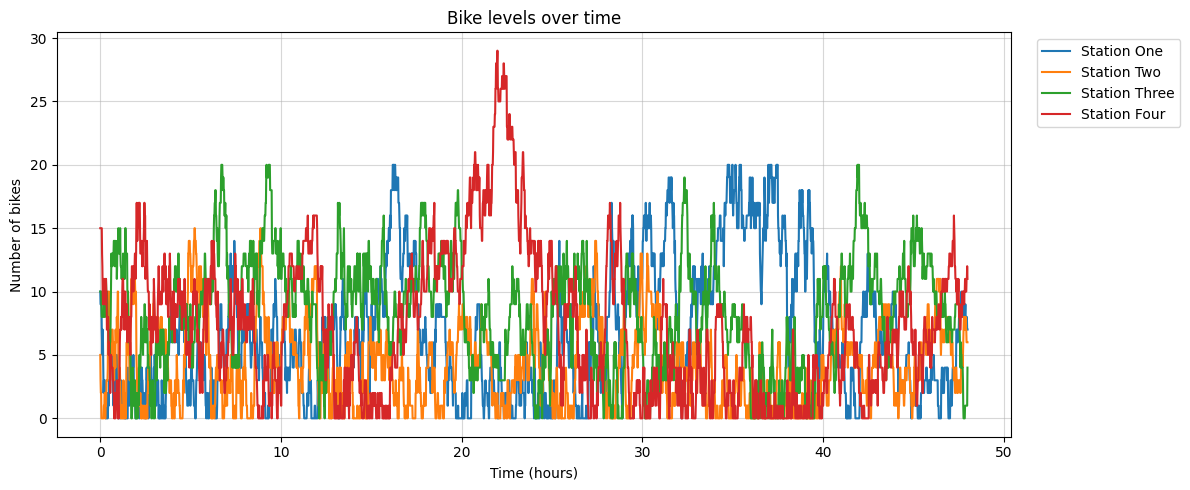

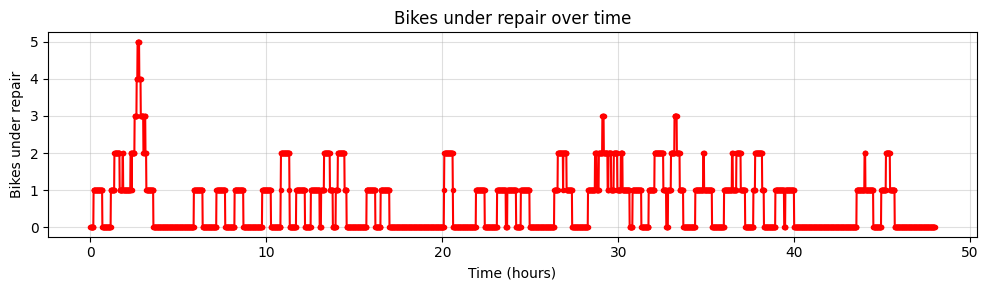

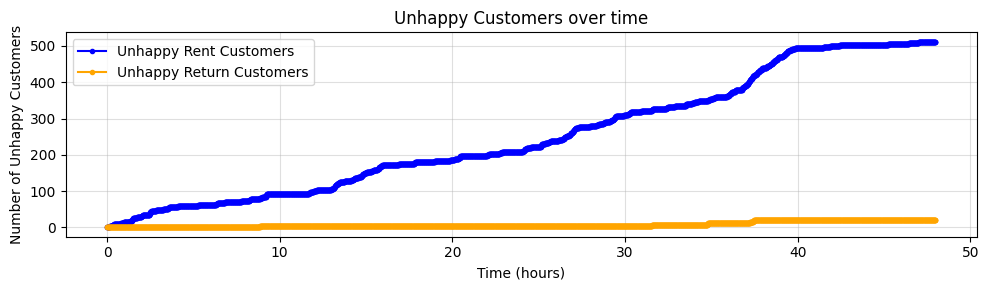

In [27]:
plot_station_levels(bike_levels)
plot_broken_bikes(bikes_under_repair)
plot_unhappy_customers(unhappy_rent, unhappy_return)

In [32]:
# simularea 2

# resetam variabilele globale
current_broken_bike = 0
unhappy_customers_rent = 0
unhappy_customers_return = 0
bikes_under_repair = []
unhappy_rent = []
unhappy_return = []

# schimbam date

REPAIR_TIME = 10
REBALANCE_TIME = 15

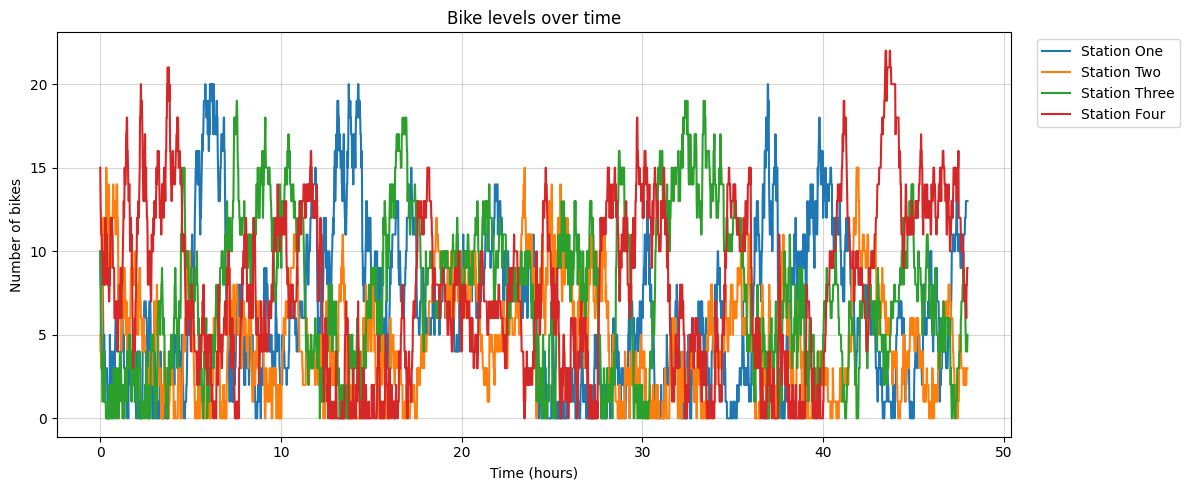

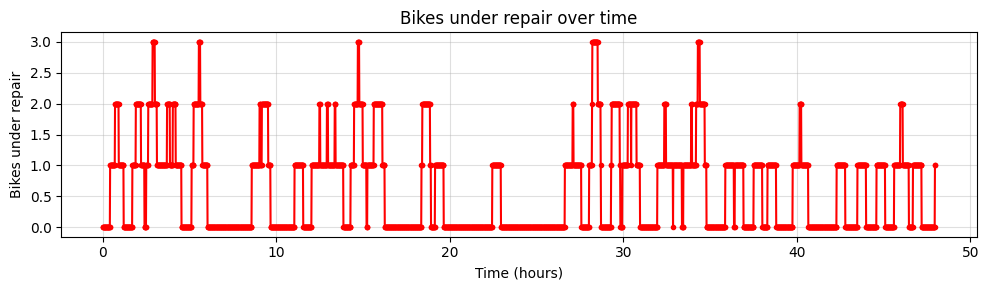

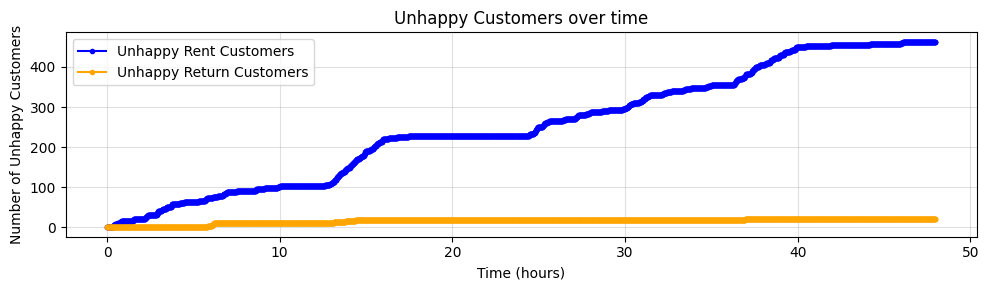

In [34]:
# plot
plot_station_levels(bike_levels)
plot_broken_bikes(bikes_under_repair)
plot_unhappy_customers(unhappy_rent, unhappy_return)

In [41]:
# simularea 3
MIN_PER_DAY = 1440
BREAKDOWN_PROB = 0.5
REPAIR_TIME = 45

REBALANCE_TIME = 30
REBALACE_TRESHOLD = 30
REBALANCE_BIKE_COUNT = 3

current_broken_bike = 0
unhappy_customers_rent = 0
unhappy_customers_return = 0
bikes_under_repair = []
unhappy_rent = []
unhappy_return = []

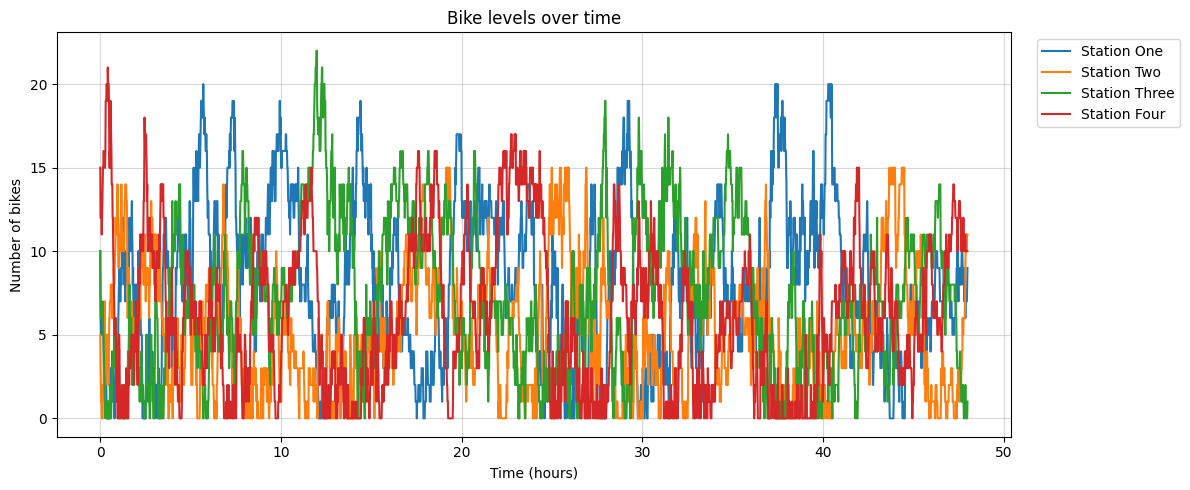

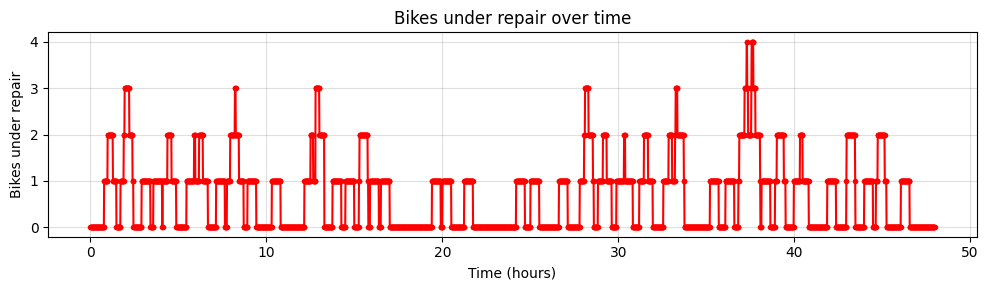

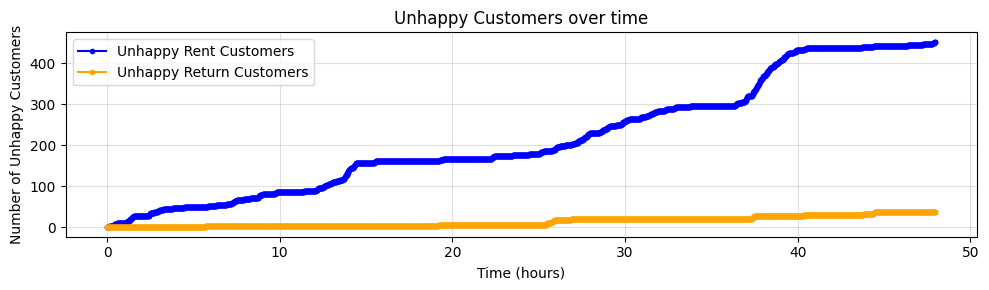

In [43]:
# plot
plot_station_levels(bike_levels)
plot_broken_bikes(bikes_under_repair)
plot_unhappy_customers(unhappy_rent, unhappy_return)